# Задача: Анализ эффективности нового алгоритма рекомендаций в условиях асимметричного и зашумленного распределения
### Контекст:
Крупная стриминговая платформа (аналог YouTube или Twitch) разработала новый алгоритм рекомендаций контента (алгоритм B), который, как ожидается, должен увеличить среднее время просмотра на пользователя по сравнению со старым алгоритмом (A).

Было проведено A/B-тестирование:

- **Группа A (Контрольная)**: 5000 пользователей, старый алгоритм.

- **Группа B (Тестовая)**: 5000 пользователей, новый алгоритм.

По итогам двухнедельного теста вы собрали данные по ключевой метрике — **«Общее время просмотра на пользователя за тест (в минутах)»**.

**Данные и их особенности:**

**Не нормальность:** Распределение метрики в обеих группах сильно отличается от нормального. Оно имеет типичный для поведенческих данных "длинный хвост":

- Большинство пользователей смотрят немного (пик в районе 0-50 минут).

- Небольшая группа "супер-зрителей" смотрит очень много (сотни и тысячи минут), формируя длинный правый хвост распределения.

**Асимметрия влияния:** Новый алгоритм B целенаправленно меняет опыт именно активных пользователей, в то время как для "пассивных" зрителей разница неочевидна. Это означает, что различие между группами может быть не сдвигом всего распределения, а изменением в правом хвосте.

**Наличие выбросов:** В данных присутствуют экстремальные выбросы (например, пользователи, которые оставляли видео фоном на всю ночь).

Вам предоставлен датасет _ab_test_results.csv_ со следующими колонками:

 - _user_id_

 - _group (A или B)_

 - _total_watch_time_min_

### Задания:


- **Проведите тест Манна-Уитни (Mann-Whitney U test)**. Сформулируйте нулевую и альтернативную гипотезы. Интерпретируйте p-value. Можно ли на его основе сделать однозначный вывод о превосходстве алгоритма B?

- Чтобы исследовать "асимметричное влияние", проведите анализ разниц не только в центре распределения, но и в хвостах. **Рассчитайте и визуализируйте разницу между группами для 75-го, 90-го и 95-го процентилей**.

- **Сформулируйте итоговый вывод:**

    - Эффективен ли новый алгоритм B?

    - На какую именно группу пользователей он оказывает наибольшее влияние?

    - Какой метод анализа оказался наиболее информативным в данном случае и почему?

    - Дайте рекомендацию о возможности запуска алгоритма на всю аудиторию.



In [50]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [85]:
df = pd.read_csv(r'C:\IDE\A B test\Homework\ab_test_results.csv')

print(f'''Dataset Summary:
Total users: {len(df)}
Group A: {len(df[df['group'] == 'A'])}
Group B: {len(df[df['group'] == 'B'])}

Descriptive Statistic bu Group:
{df.groupby(['group']).describe()}

H_0: total_watch_time_min_A = total_watch_time_min_B - Распределение общего времени просмотра на пользователя группы А и группы В равны.
H_1: total_watch_time_min_В != total_watch_time_min_А - Распределение общего времени просмотра на пользователя групп A и В отличаются.
''')

print(f'Key Percentiles by Group:')
percentiles = [0.75, 0.9, 0.95]
for p in percentiles:
    p_val = p * 100
    a_val = np.percentile(df[df['group'] == 'A']['total_watch_time_min'], p_val)
    b_val = np.percentile(df[df['group'] == 'B']['total_watch_time_min'], p_val)
    diff = b_val - a_val
    print(f"{p_val:.0f}th percentile: A={a_val:.1f}, B={b_val:.1f}, Difference={diff:.1f}")

mw_stat, mw_p = stats.mannwhitneyu(
    df[df['group'] == 'A']['total_watch_time_min'],
    df[df['group'] == 'B']['total_watch_time_min'],
    alternative= 'two-sided' #'less' #'greater' #'two-sided'
)

print(f"\nMann-Whitney U Test: p-value = {mw_p:.6f}")



Dataset Summary:
Total users: 10000
Group A: 5000
Group B: 5000

Descriptive Statistic bu Group:
      total_watch_time_min                                                    \
                     count       mean         std  min        25%        50%   
group                                                                          
A                   5000.0  56.347878  262.313288  0.0  14.729144  26.834960   
B                   5000.0  71.477408  408.519252  0.0  15.383838  27.352416   

                                
             75%           max  
group                           
A      44.946309   8130.547119  
B      46.352279  11670.621483  

H_0: total_watch_time_min_A = total_watch_time_min_B - Распределение общего времени просмотра на пользователя группы А и группы В равны.
H_1: total_watch_time_min_В != total_watch_time_min_А - Распределение общего времени просмотра на пользователя групп A и В отличаются.

Key Percentiles by Group:
75th percentile: A=44.9, B=46.4, Diff

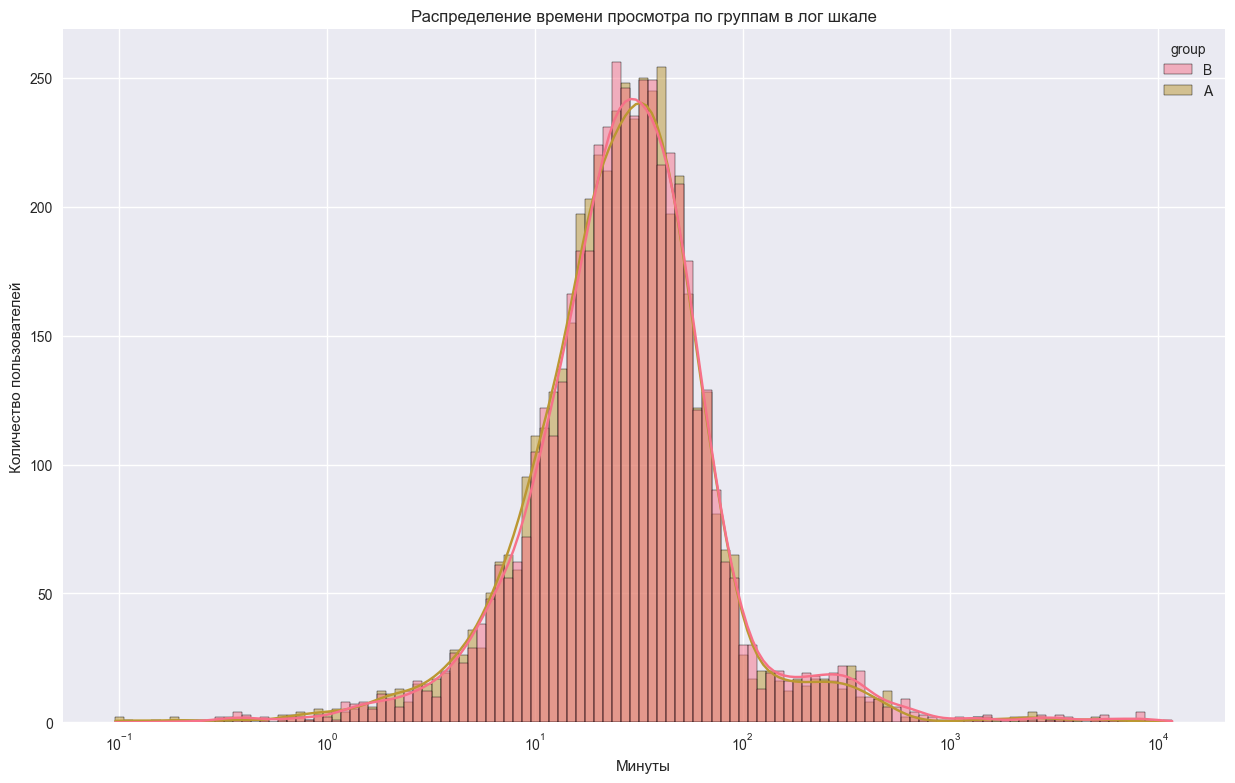

In [86]:
df_plot = df[np.isfinite(df['total_watch_time_min'])]
df_plot = df_plot[df_plot['total_watch_time_min'] > 0]
plt.figure(figsize=(15, 9))
sns.histplot(data=df_plot, x='total_watch_time_min', hue='group', kde=True, log_scale=True)

plt.title('Распределение времени просмотра по группам в лог шкале')
plt.xlabel('Минуты')
plt.ylabel('Количество пользователей')
plt.show()

# Задание 1
H_0: total_watch_time_min_A = total_watch_time_min_B - Распределение общего времени просмотра на пользователя группы А и группы В равны.

H_1: total_watch_time_min_В != total_watch_time_min_А - Распределение общего времени просмотра на пользователя групп A и В отличаются.

Mann-Whitney U Test: p-value = 0.045342, если p-value меньше уровня значимости (в нашем случае 0,05), то нулевая гипотеза отвергается. Значит между группами A и B есть статистически значимые различия. Однозначные выводы о превосходстве алгоритма B сделать нельзя, можно быть уверенным только в наличии статистически значимых различий.

# Задание 2
Key Percentiles by Group:

75th percentile: A=44.9, B=46.4, Difference=1.4

90th percentile: A=71.5, B=76.2, Difference=4.7

95th percentile: A=119.3, B=153.6, Difference=34.3

В соответствии с значениями метрики в процентилях можно сказать, что да, алгоритм В эффективен.

Но наиболее эффективен данный алгоритм для наиболее активных пользователей, попавших в 95й процентиль.

Наиболее эффективен в данном случае метод вычисления процентилей, так как он не только показывает значимое различие между алгоритмами.  Но и позволяет понять равномерно ли между пользователями распределяется данное различие. То есть одинаково ли эффективен новый алгоритм для всех категорий пользователей.

Учитывая условия задания, алгоритм рекомендован к запуску, так как он показывает статистически значимое улучшение исследуемой метрики для всей массы пользвателей. Возможно, стоит учесть практическую значимость внедрения алгоритма, но в данной задаче для этого недостаточно данных.

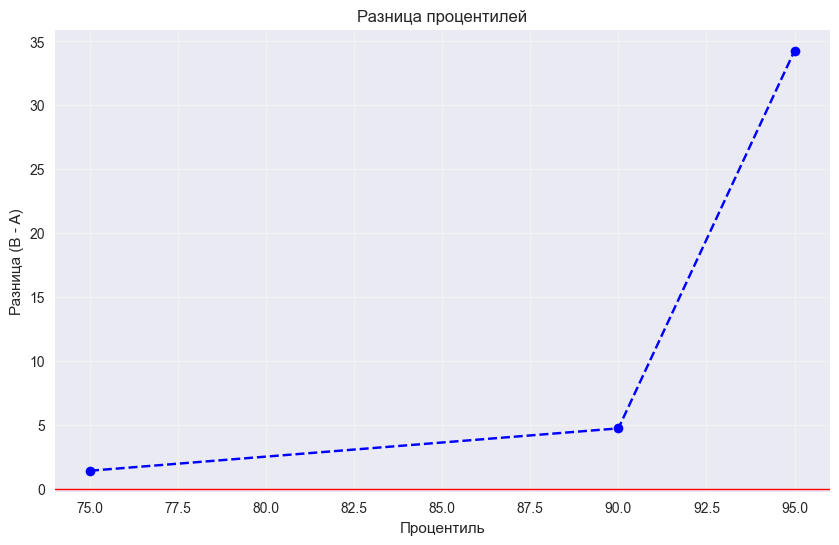

In [88]:
def plot_percentiles(data_a, data_b, percentiles=[75, 90, 95]):
    # Визуализирует разницу между группами в разных точках распределения
    diffs = []

    for p in percentiles:
        diff = np.percentile(data_b, p) - np.percentile(data_a, p)
        diffs.append(diff)
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    plt.plot(percentiles, diffs, marker='o', linestyle='--', color='b')
    plt.axhline(0, color='red', lw=1) # Линия отсутствия эффекта
    plt.xlabel('Процентиль')
    plt.ylabel('Разница (B - A)')
    plt.title('Разница процентилей')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_percentiles(df[df['group'] == 'A']['total_watch_time_min'], df[df['group'] == 'B']['total_watch_time_min'])